<a href="https://www.kaggle.com/code/sonawanelalitsunil/youtube-video-statistics-metadata-2025-98-67?scriptVersionId=259243225" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/youtube-video-statistics-and-metadata/Youtube Data.csv


## Title:
📊 YouTube Video Statistics & Metadata (2025)

## Description (detailed):
This dataset contains comprehensive information on YouTube videos published in 2025, including both technical attributes and engagement statistics. It covers key metadata such as video ID, title, description, category, hashtags, duration, resolution, frame rate, bitrate, and codec details. Additionally, it includes performance metrics like views, likes, and comments, which allow for in-depth analysis of audience interaction and video popularity.

The dataset can be used for a variety of applications such as trend analysis, recommendation systems, content optimization, and machine learning models that predict video success.

## Import dataset

In [2]:
df = pd.read_csv(
    "/kaggle/input/youtube-video-statistics-and-metadata/Youtube Data.csv",
    quotechar='"',
    engine="python",
    on_bad_lines="skip"   # skips incomplete/broken rows
)

In [3]:
df.head()

,video_id,title,description,published_at,channel_id,channel_title,tags,category_id,view_count,like_count,favorite_count,comment_count,duration,definition,caption
0,kZfz5UlsHlQ,"DARLING, I (Official Video)","directed by TYLER OKONMA\ndp: LUIS ""PANCH"" PER...",2025-08-19T17:09:11Z,UCsQBsZJltmLzlsJNG7HevBg,"Tyler, The Creator","chromakopia,tyler the creator,darling i,teezo ...",2,1042576,181841,0,13958,PT4M49S,hd,False
1,9txkGBj_trg,Call of Duty: Black Ops 7 | Gameplay Reveal Tr...,Call of Duty®: Black Ops 7 redefines the franc...,2025-08-19T18:08:38Z,UC9YydG57epLqxA9cTzZXSeQ,Call of Duty,"call of duty,cod,activision",20,5991411,25012,0,13127,PT2M20S,hd,False
2,HVC_dBNUZGc,gamescom Opening Night Live 2025,Live from Cologne – the big opening show of ga...,2025-08-19T20:15:33Z,UCHo_GVNoKNqfJx6zUGRd6YQ,gamescom,NaN,24,1540057,35942,0,667,PT3H14S,hd,False
3,5dA094oAy-g,Twenty One Pilots - Drum Show (Official Video),Official video for the new single “Drum Show” ...,2025-08-18T17:30:06Z,UCBQZwaNPFfJ1gZ1fLZpAEGw,twenty one pilots,"twenty one pilots,twenty one pilots official,n...",10,1973975,212769,0,14911,PT3M36S,hd,False
4,NZY5WiqeyQQ,Fallout Season 2 - Official Teaser Trailer | g...,"Watch the Season 2 Teaser Trailer for Fallout,...",2025-08-19T18:55:58Z,UCKy1dAqELo0zrOtPkf0eTMw,IGN,"ign,gamescom,gamescom 2025,game trailer,game t...",20,831185,58015,0,4846,PT2M43S,hd,False


In [4]:
df.tail()

,video_id,title,description,published_at,channel_id,channel_title,tags,category_id,view_count,like_count,favorite_count,comment_count,duration,definition,caption
371,4FFzWTaFb3hs,BAK Jay Feat. Chuckyy - Riding With That (Offi...,BAK Jay - Riding With That Ft. Chuckyy\nShot ...,2025-08-19T20:00:07Z,UC9n0bFMw6qvIEBPRnOSxwzw,B.A.K Jay,NaN,10,43678,5263,0,377,PT2M22S,hd,False
372,H4bq6P8e5gk,Bubsy 4D - Official Announcement Trailer,Bubsy's back baby and this time it's in 4D! Jo...,2025-08-19T17:40:18Z,UC33t-fSHCIFjvMUhWhJHX6g,Atari,NaN,20,214623,19542,0,4813,PT1M38S,hd,False
373,2qTcR8OE5AI,I Opened Another Grocery Store…,CaseOh X Starforge https://starforgepc.com/Ca...,2025-08-19T22:00:02Z,UC63anZxfVGHUEmfBAf5w7pw,CaseOh,"gaming,caseoh,caseohgames,case,funny,streamer,...",20,146444,10967,0,1050,PT1H3M26S,hd,False
374,HGo6poEydWs,THF LIL LAW - BLASIAN DOLL,Sounds like laws back With the track Blasian d...,2025-08-19T19:45:26Z,UCpbVuAz2yFpNVp0V55ksbXw,THF LIL LAW,NaN,10,26095,1735,0,45,PT2M14S,hd,False
375,q4-CRkd_74g,Good Boy - Official Trailer | HD | IFC Films,A loyal dog moves to a rural family home with ...,2025-08-18T16:30:28Z,UCOn923UnbV8H9zo_lO6ZCRw,IFC Films,"Good Boy,Goodboy,Good Boy movie,Goodboy movie,...",1,372690,11896,0,1145,PT1M42S,hd,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   video_id        376 non-null    object
 1   title           376 non-null    object
 2   description     376 non-null    object
 3   published_at    376 non-null    object
 4   channel_id      376 non-null    object
 5   channel_title   376 non-null    object
 6   tags            243 non-null    object
 7   category_id     376 non-null    int64 
 8   view_count      376 non-null    int64 
 9   like_count      376 non-null    int64 
 10  favorite_count  376 non-null    int64 
 11  comment_count   376 non-null    int64 
 12  duration        376 non-null    object
 13  definition      376 non-null    object
 14  caption         376 non-null    bool  
dtypes: bool(1), int64(5), object(9)
memory usage: 41.6+ KB


In [6]:
df.describe()

,category_id,view_count,like_count,favorite_count,comment_count
count,376.000000,3.760000e+02,376.00000,376.0,376.000000
mean,13.747340,3.847002e+05,20558.87500,0.0,1725.598404
std,6.942237,5.596647e+05,25777.93542,0.0,1811.052962
min,1.000000,2.609500e+04,156.00000,0.0,0.000000
25%,10.000000,1.464440e+05,5263.00000,0.0,377.000000
50%,20.000000,2.060280e+05,12547.00000,0.0,1481.000000
75%,20.000000,3.457330e+05,19542.00000,0.0,2520.000000
max,24.000000,5.991411e+06,212769.00000,0.0,14911.000000


In [7]:
df.dtypes

video_id          object
title             object
description       object
published_at      object
channel_id        object
channel_title     object
tags              object
category_id        int64
view_count         int64
like_count         int64
favorite_count     int64
comment_count      int64
duration          object
definition        object
caption             bool
dtype: object

In [8]:
df.shape

(376, 15)

In [9]:
df.isnull().sum()

video_id            0
title               0
description         0
published_at        0
channel_id          0
channel_title       0
tags              133
category_id         0
view_count          0
like_count          0
favorite_count      0
comment_count       0
duration            0
definition          0
caption             0
dtype: int64

In [10]:
df.duplicated().sum()

339

In [11]:
df.columns

Index(['video_id', 'title', 'description', 'published_at', 'channel_id',
       'channel_title', 'tags', 'category_id', 'view_count', 'like_count',
       'favorite_count', 'comment_count', 'duration', 'definition', 'caption'],
      dtype='object')

## Data viusliazations

In [12]:
# Convert published_at to datetime
df['published_at'] = pd.to_datetime(df['published_at'], errors='coerce')

# Convert counts to numeric
for col in ['view_count', 'like_count', 'favorite_count', 'comment_count']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

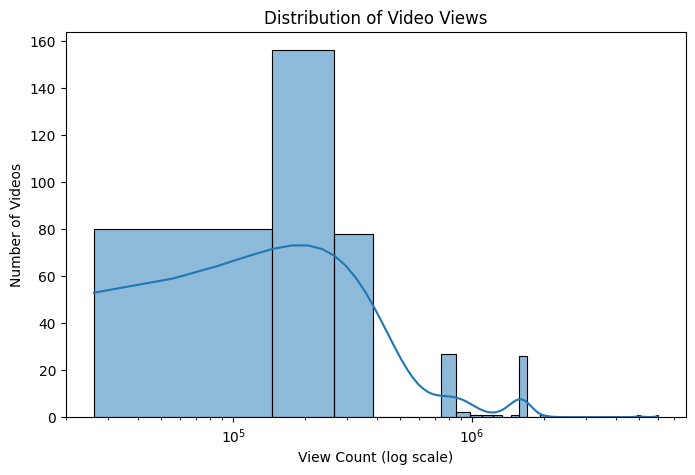

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['view_count'], bins=50, kde=True)
plt.xscale("log")  # log scale to handle skewness
plt.title("Distribution of Video Views")
plt.xlabel("View Count (log scale)")
plt.ylabel("Number of Videos")
plt.show()

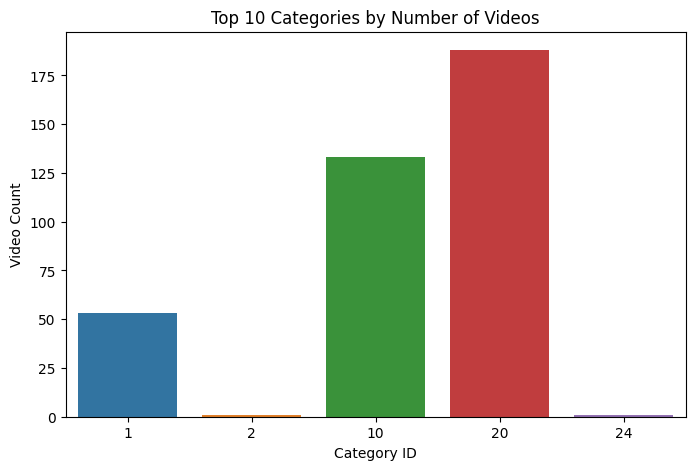

In [14]:
plt.figure(figsize=(8,5))
category_counts = df['category_id'].value_counts().head(10)
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.title("Top 10 Categories by Number of Videos")
plt.xlabel("Category ID")
plt.ylabel("Video Count")
plt.show()

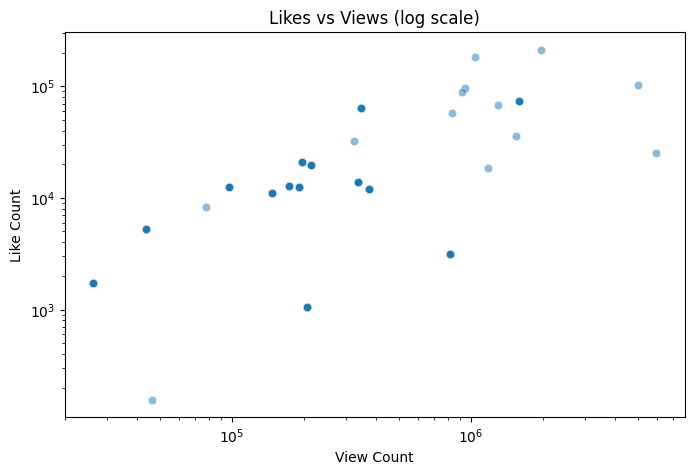

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="view_count", y="like_count", alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.title("Likes vs Views (log scale)")
plt.xlabel("View Count")
plt.ylabel("Like Count")
plt.show()

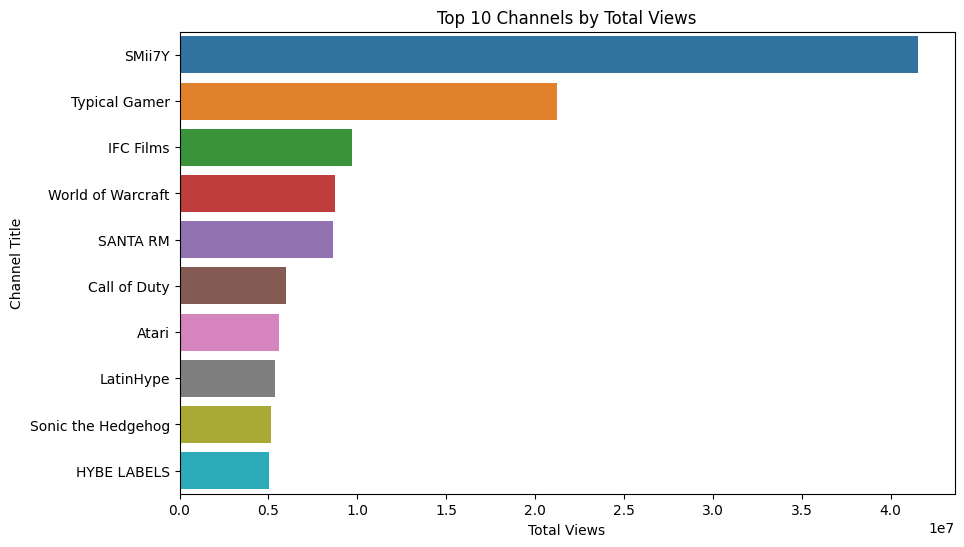

In [16]:
plt.figure(figsize=(10,6))
top_channels = df.groupby('channel_title')['view_count'].sum().nlargest(10)
sns.barplot(y=top_channels.index, x=top_channels.values)
plt.title("Top 10 Channels by Total Views")
plt.xlabel("Total Views")
plt.ylabel("Channel Title")
plt.show()

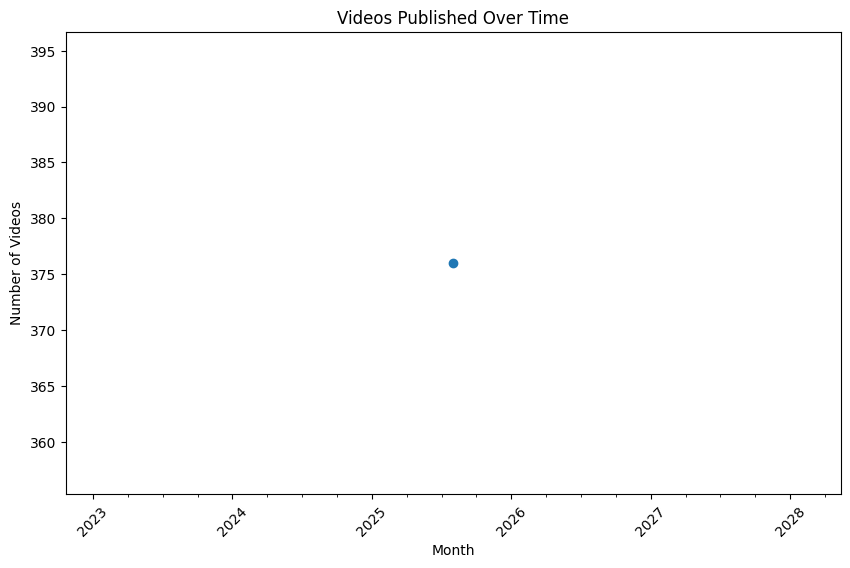

In [17]:
plt.figure(figsize=(10,6))
df['published_month'] = df['published_at'].dt.to_period('M')
videos_per_month = df.groupby('published_month').size()
videos_per_month.plot(kind='line', marker='o')
plt.title("Videos Published Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Videos")
plt.xticks(rotation=45)
plt.show()


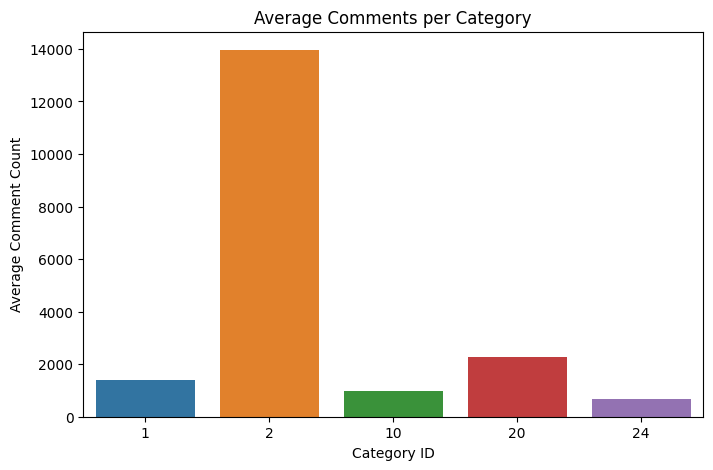

In [18]:
plt.figure(figsize=(8,5))
avg_comments = df.groupby('category_id')['comment_count'].mean().nlargest(10)
sns.barplot(x=avg_comments.index, y=avg_comments.values)
plt.title("Average Comments per Category")
plt.xlabel("Category ID")
plt.ylabel("Average Comment Count")
plt.show()

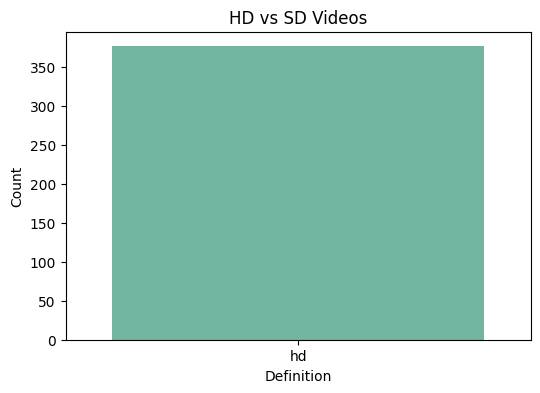

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x="definition", data=df, palette="Set2")
plt.title("HD vs SD Videos")
plt.xlabel("Definition")
plt.ylabel("Count")
plt.show()

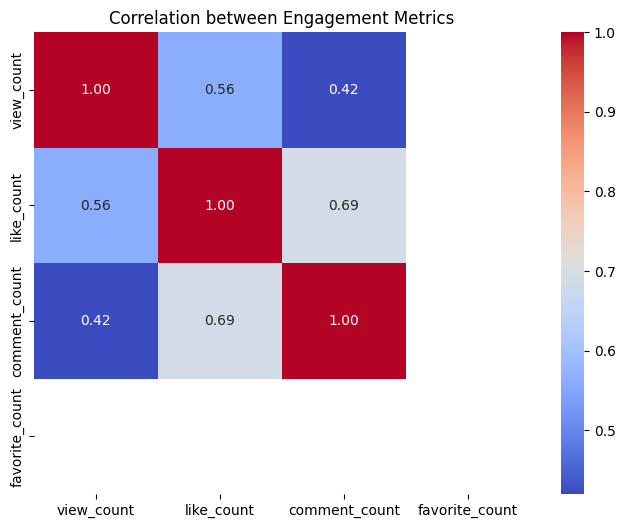

In [20]:
plt.figure(figsize=(8,6))
corr = df[['view_count','like_count','comment_count','favorite_count']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Engagement Metrics")
plt.show()

## Predictive modeling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

Model Accuracies (in %):
Random Forest: 98.67
Gradient Boosting: 98.67
SVM: 98.67
Logistic Regression: 97.33
Decision Tree: 97.33
KNN: 96.0
Naive Bayes: 85.33
XGBoost: Error: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got [ 1 10 20]


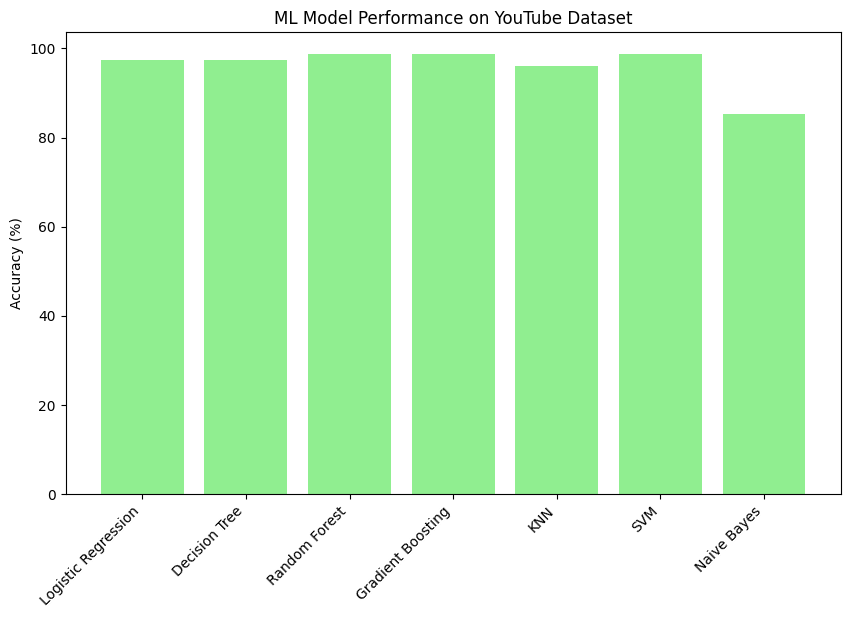

In [22]:
drop_cols = ['video_id', 'channel_id']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

categorical_cols = ['title', 'description', 'channel_title', 'tags', 'definition', 'caption']
for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['category_id'])
y = df['category_id']

# Remove rare classes (only 1 sample)
valid_classes = y.value_counts()[y.value_counts() > 1].index
mask = y.isin(valid_classes)
X, y = X[mask], y[mask]

# ✅ Keep only numeric features
X = X.select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="mlogloss")
}


results = {}
for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds) * 100
        results[name] = round(acc, 2)
    except Exception as e:
        results[name] = f"Error: {str(e)}"

print("Model Accuracies (in %):")
for model, acc in sorted(results.items(), key=lambda x: (isinstance(x[1], float), x[1]), reverse=True):
    print(f"{model}: {acc}")

valid_results = {k: v for k, v in results.items() if isinstance(v, float)}

plt.figure(figsize=(10,6))
plt.bar(valid_results.keys(), valid_results.values(), color='lightgreen')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy (%)")
plt.title("ML Model Performance on YouTube Dataset")
plt.show()


## Thank you...pls upvote!!!!